**Proyecto:** Análisis de la Mortalidad Fetal Potencialmente Prevenible en   Ecuador mediante Clustering y Modelos de Clasificación para la Identificación de Perfiles de Vulnerabilidad Materna

---



**Antecedentes: **En el entregable de la Semana 2 "1. S2_Izquierdo_Nicole_Capstone: Selección y Descripción Dataset" ya se realizó un proceso de limpieza y normalización del Dataset, el cual consistió en:

**1. Corrección de Codificación (BOM):** Se detectó la presencia de caracteres Byte Order Mark (ï»¿) en el encabezado del archivo original, los cuales fueron eliminados mediante la decodificación utf-8-sig para permitir el acceso correcto a la primera variable (prov_insc).

**2. Normalización de Metadatos:** Se aplicó una función de limpieza de espacios en blanco (stripping) a los nombres de las 43 variables para evitar errores de referencia en el diccionario de datos.

**3. Depuración de Registros Malformados:** Durante la carga, se descartaron registros con inconsistencias en los delimitadores (filas con exceso de columnas por errores de digitación en origen), resultando en una cantidad efectiva de 1.328 registros.

**4. Alineación con Diccionario ANDA-INEC:** Se vincularon las variables técnicas con sus descripciones oficiales para asegurar la trazabilidad institucional del estudio.

**5. Detección de Valores Atípicos**

Se identificaron las variables que presentan códigos de no respuesta, con el fin de determinar la estrategia de limpieza y evitar sesgos en el algoritmo de agrupamiento.

**6. Refinamiento por Criterio de Variables Críticas**

Dentro de las variables que presentan valores atípicos, se han identificado un conjunto de 7 variables críticas que representan el perfil socio-demográfico y clínico necesario para el modelado de vulnerabilidad: edad_mad, sem_gest, con_pren, niv_inst, sabe_leer, etnia y est_civil.

Para asegurar la precisión del algoritmo de Clustering, se opta por una depuración que consiste en la eliminación de los registros que presenten omisiones o falta de información en cualquiera de estas dimensiones.

Esto permite trabajar con datos de integridad elevada, evitando que valores nulos distorsionen la formación de los grupos de riesgo.

**7. Imputación de Variables Antropométricas**

Se han identificado 2 variales continuas (peso y talla) que presentan valores atípicos, se optó por una estrategia de imputación por mediana, esta decisión se fundamenta en la capacidad de la mediana para resistir la influencia de valores atípicos presentes en los registros de defunciones fetales.

Al mantener la tendencia central de la muestra, se preserva la integridad del volumen de datos sin sesgar las mediciones físicas que son críticas para la determinación de los clústeres de riesgo.

**8. Imputación de Variables de Antecedentes de Paridad**

Para las variables (hij_viv) e (hij_vivm), los registros identificados con la etiqueta "Sin información" fueron tratados mediante imputación por moda. Se selecciona esta técnica debido a que estas variables son de naturaleza discreta y presentan una distribución sesgada donde la mayoría de la población se concentra en un valor específico. Este procedimiento permite conservar la representatividad de la muestra sin introducir distorsiones significativas en el cálculo de distancias para el Clustering.

**9. Justificación de Variables Sin Intervención**

Se ha determinado no aplicar procesos de depuración, transformación o imputación sobre las variables (nac_mad) nacionalidad de la madre y (dia_mad) día de nacimiento de la madre debido a que estas dimensiones actúan como datos de registro civil y control de identidad, careciendo de una relación causal directa con la variabilidad biológica del fenómeno de mortalidad fetal en el contexto de este modelo de clustering, sin embargo, se optó por conservar estas variables en su estado original únicamente para fines de consulta o trazabilidad de los datos, garantizando que el espacio de características del modelo se concentre exclusivamente en factores clínicos y sociodemográficos de alto impacto.


---




**Consolidación del Dataset**

Tras completar el ciclo de preprocesamiento, se consolida el Dataset que constituye el universo total de la investigación, esta base de datos representa la totalidad de los registros depurados que cumplen con estándares de calidad adecuados

La eliminación de ruidos y la normalización garantizan que cualquier inferencia realizada sobre este universo sea estadísticamente sólida.

In [3]:
# =========================
# 1. Importar librerías
# =========================
import pandas as pd
import numpy as np

# =========================
# 2. Selección de archivo
# =========================
from google.colab import files
uploaded = files.upload()

# =========================
# 3. Cargar el dataset
# =========================
df = pd.read_csv("dataset__limpio.csv")

# =========================
# 4. Cálculo de métricas
# =========================
n_registros = df.shape[0]
n_variables = df.shape[1]

total_celdas = n_registros * n_variables
celdas_no_nulas = df.notna().sum().sum()
indice_integridad = (celdas_no_nulas / total_celdas) * 100

# =========================
# 5. Tabla resumen
# =========================
resumen_dataset = pd.DataFrame({
    "Indicador": [
        "Universo total de registros (N)",
        "Número de variables",
        "Índice de integridad (%)"
    ],
    "Valor": [
        n_registros,
        n_variables,
        round(indice_integridad, 2)
    ]
})

# =========================
# 6. Mostrar tabla
# =========================
resumen_dataset


Saving dataset__limpio.csv to dataset__limpio (3).csv


,Indicador,Valor
0,Universo total de registros (N),1184.00
1,Número de variables,43.00
2,Índice de integridad (%),99.94


El dataset analizado cuenta con un universo total de 1.184 registros y 43 variables de análisis. El Índice de Integridad global (99.94%) evidencia un alto nivel de completitud de la información, lo que permite avanzar hacia las etapas de análisis.

---



**Integridad por Variable**

A continuación se presenta una tabla que muestra la integridad por cada una de las variables del Dataset

In [10]:
import pandas as pd
from IPython.display import display, HTML

# =========================
# 1. Tabla base de variables
# =========================
tabla_variables = pd.DataFrame({
    "Variable": df.columns,
    "Tipo Original": df.dtypes.astype(str),
    "Registros totales": len(df),
    "Registros no nulos": df.notna().sum().values,
    "Registros nulos": df.isna().sum().values
})

tabla_variables["% Completitud"] = (
    tabla_variables["Registros no nulos"] / tabla_variables["Registros totales"] * 100
).round(2)

tabla_variables["% Missing"] = (
    tabla_variables["Registros nulos"] / tabla_variables["Registros totales"] * 100
).round(2)

# =========================
# 2. Clasificación de variables
# =========================
def clasificar(row):
    nom = row['Variable'].lower()
    tipo = row['Tipo Original']
    if 'fecha' in nom:
        return 'Temporal (Fecha)'
    elif any(x in nom for x in ['anio', 'mes', 'dia']):
        return 'Temporal (Componente)'
    elif 'int' in tipo:
        return 'Numérica (Discreta)'
    elif 'float' in tipo:
        return 'Numérica (Continua)'
    else:
        return 'Categórica (Cualitativa)'

tabla_variables['Tipo'] = tabla_variables.apply(clasificar, axis=1)

# =========================
# 3. Agregar descripción desde diccionario
# =========================
tabla_variables['Descripción'] = tabla_variables['Variable'].map(diccionario_completo)

# Reordenar columnas para mejor lectura
tabla_variables = tabla_variables[[
    'Variable',
    'Descripción',
    'Tipo Original',
    'Tipo',
    'Registros totales',
    'Registros no nulos',
    'Registros nulos',
    '% Completitud',
    '% Missing'
]]

# Ordenar por nivel de completitud
tabla_variables = tabla_variables.sort_values(
    by='% Completitud',
    ascending=True
).reset_index(drop=True)

# =========================
# 4. Estilo visual (centrado)
# =========================
estilo_tabla = """
<style>
    table {
        width: 100%;
        border-collapse: collapse;
    }
    th {
        background-color: #2c3e50;
        color: white;
        text-align: center !important;
        padding: 10px;
    }
    td {
        text-align: center !important;
        padding: 8px;
        border: 1px solid #ddd;
    }
    tr:nth-child(even) {background-color: #f2f2f2;}
    tr:hover {background-color: #ddd;}
</style>
"""

# =========================
# 5. Renderizar tabla final
# =========================
display(HTML(estilo_tabla + tabla_variables.to_html(index=False)))


Variable,Descripción,Tipo Original,Tipo,Registros totales,Registros no nulos,Registros nulos,% Completitud,% Missing
dia_mad,Día de nacimiento de la madre,float64,Temporal (Componente),1184,1154,30,97.47,2.53
nac_mad,Nacionalidad de la madre,object,Categórica (Cualitativa),1184,1183,1,99.92,0.08
prov_insc,Provincia donde se inscribe la defunción fetal,object,Categórica (Cualitativa),1184,1184,0,100.00,0.00
cant_insc,Cantón donde se inscribe la defunción fetal,object,Categórica (Cualitativa),1184,1184,0,100.00,0.00
mes_insc,Mes de inscripción de la defunción fetal,int64,Temporal (Componente),1184,1184,0,100.00,0.00
dia_insc,Día de inscripción de la defunción fetal,int64,Temporal (Componente),1184,1184,0,100.00,0.00
parr_insc,Parroquia donde se inscribe la defunción fetal,object,Categórica (Cualitativa),1184,1184,0,100.00,0.00
anio_insc,Año de inscripción de la defunción fetal,int64,Temporal (Componente),1184,1184,0,100.00,0.00
peso,Peso del feto (gramos a 4 dígitos),float64,Numérica (Continua),1184,1184,0,100.00,0.00
sem_gest,Semanas de gestación,int64,Numérica (Discreta),1184,1184,0,100.00,0.00


La clasificación de variables se realizó considerando tanto el tipo técnico del dato como su rol analítico, permitiendo diferenciar variables temporales, numéricas y categóricas de forma consistente con su uso posterior en análisis exploratorio y modelado.

---



**Subconjuntos y definición de variables de interés**

Para el desarrollo del análisis se identificaran variables clave, clasificadas según su rol dentro del modelo analítico, orientadas a capturar la desigualdad en el acceso a la salud y el riesgo reproductivo:

**Variables explicativas**

Incluyen dimensiones geográficas, biológicas, contextuales y de atención que actúan como determinantes del desenlace fetal.

**1. Variables Geográficas:** Identifican los nodos críticos de mortalidad y las brechas de infraestructura. El análisis del Área, urbana o rural, es fundamental para evidenciar la desigualdad, ya que las zonas rurales suelen presentar mayores barreras de acceso, deficiencias en el transporte y tiempos de traslado más prolongados hacia centros de especialidad.

El contraste entre el lugar de residencia y el de fallecimiento permite, además, inferir la lejanía como un factor de riesgo.

* Área de fallecimiento (area_fall)
* Provincia de fallecimiento (prov_fall)
* Cantón de fallecimiento (cant_fall)
* Parroquia de fallecimiento (parr_fall)
* Provincia de residencia de la madre (prov_res)
* Cantón de residencia de la madre (cant_res)
* Parroquia de residencia de la madre (parr_res)
* Área de residencia de la madre (area_res)


**2. Características Biológicas y de Desarrollo:** Estas variables permiten caracterizar la madurez física y la viabilidad del feto al momento del fallecimiento. Son indicadores directos del desarrollo intrauterino y actúan como señales de alerta sobre la salud de la madre y la efectividad de la vigilancia médica durante la gestación.

* Peso (peso)
* Talla (talla)
* Edad Gestacional (sem_gest)


**3. Determinantes de Acceso y Atención:** Miden la oportunidad y la calidad de la respuesta del sistema de salud ante el embarazo. El lugar de ocurrencia y la persona que atiende el evento reflejan el grado de institucionalización y profesionalización de la asistencia recibida, estos factores son determinantes en la evitabilidad del deceso.

* Número de Controles prenatales (con_pren)
* Persona que atendió el parto (asis_por)
* Causa que ocasionó la defunción fetal (causa_fetal)
* Lugar de ocurrencia (lugar_ocur)

**4. Factores de Vulnerabilidad Materna:** Representan el perfil sociodemográfico y educativo de la madre, estas variables son cruciales para entender cómo los determinantes sociales, nivel de instrucción, etnia o  condición de extranjería, condicionan el acceso a la información y a los servicios de salud, exponiendo a ciertos grupos a una mayor exclusión y riesgo.

* Edad de la madre (edad_mad)
* Nivel de instrucción (niv_inst)
* Alfabetismo e instrucción de la madre (sabe_leer)
* Etnia (etnia)
* Estado Civil (est_civil)
* Nacionalidad de la madre (nac_mad)

**5. Antecedentes Reproductivos:** Esta dimensión de variables actúa como un predictor de riesgo obstétrico acumulado, ya que el historial de pérdidas previas permite identificar perfiles de riesgo recurrente que requieren una atención diferenciada y una intervención más intensiva por parte de los servicios de salud.

* Hijos nacidos muertos (hij_nacm)

La creación de subconjuntos a partir de estas variables permite:

**1. Identificar patrones diferenciados de riesgo:** Al aislar, por ejemplo, el área rural o los niveles bajos de instrucción, el algoritmo puede detectar clústeres de vulnerabilidad que en el dataset general quedarían ocultos.

**2. Reducir el ruido estadístico:** Permite separar los casos de mortalidad por causas biológicas inevitables de aquellos derivados de la desigualdad territorial.

**3. Facilitar la interpretación:** Los perfiles obtenidos permiten generar recomendaciones de política pública específicas para cada territorio y grupo social.

---




**Distribuciones y detección de outliers (análisis univariado)**

El análisis de las distribuciones univariadas de las **variables biológicas y reproductivas **permite caracterizar la estructura estadística de los datos y detectar posibles valores atípicos que puedan influir en etapas posteriores de modelado. Dado que el evento analizado corresponde a defunciones fetales, es esperable encontrar distribuciones no simétricas, con colas largas y concentraciones en rangos clínicamente críticos, reflejando condiciones adversas del desarrollo intrauterino y del contexto materno.

La identificación de asimetrías, dispersiones extremas y acumulaciones en determinados valores es fundamental para evaluar la calidad de la información, distinguir entre outliers reales y posibles errores de registro, y definir estrategias adecuadas de limpieza, transformación o segmentación de los datos.

El análisis se presenta para las siguientes variables:

* Peso del feto (gramos, a cuatro dígitos)
* Talla del feto
* Semanas de gestación
* Edad de la madre
* Controles prenatales recibidos
* Hijos nacidos muertos

Las variables continuas se visualizan mediante histogramas acompañados de estimaciones de densidad (KDE), mientras que las variables discretas se visualizan utilizando histogramas con valores enteros, garantizando una interpretación coherente con su naturaleza y evitando distorsiones asociadas a interpolaciones no significativas.

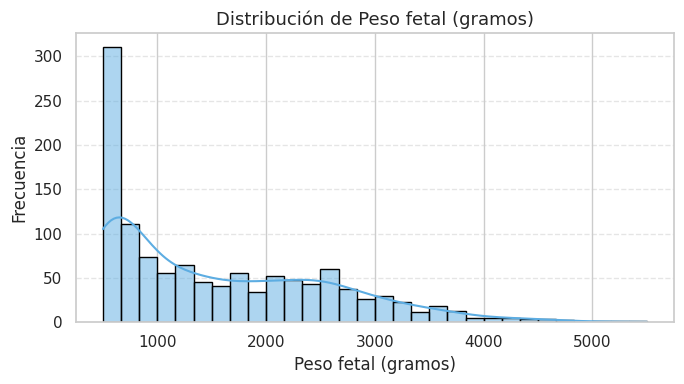

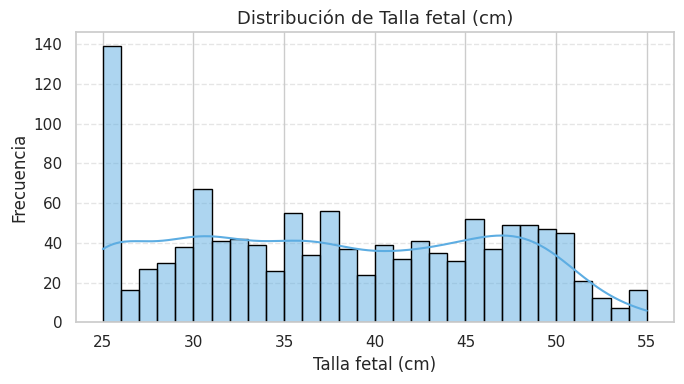

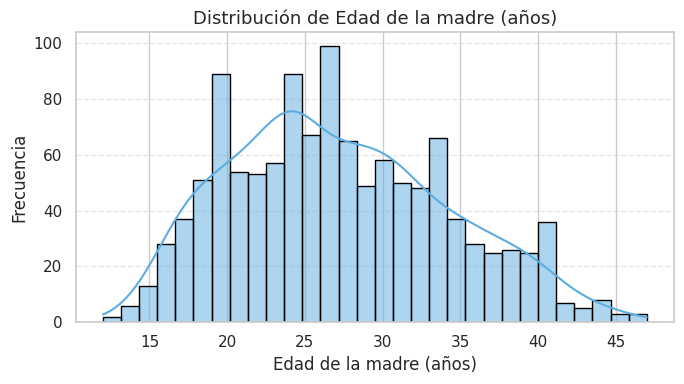

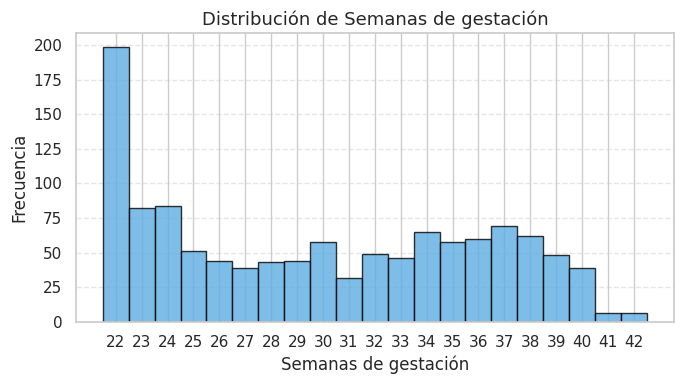

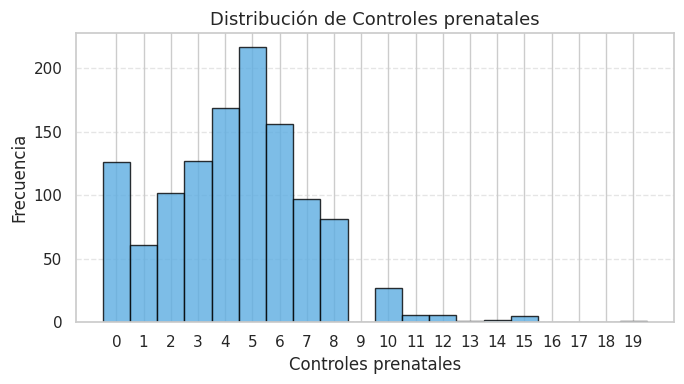

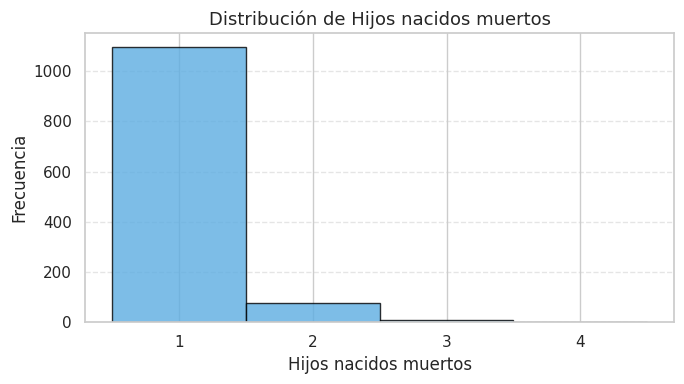

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Variables
variables_continuas = ['peso', 'talla', 'edad_mad']
variables_discretas = ['sem_gest', 'con_pren', 'hij_nacm']

# Diccionario de títulos (mismos que boxplots)
titulos = {
    'peso': 'Peso fetal (gramos)',
    'talla': 'Talla fetal (cm)',
    'sem_gest': 'Semanas de gestación',
    'edad_mad': 'Edad de la madre (años)',
    'con_pren': 'Controles prenatales',
    'hij_nacm': 'Hijos nacidos muertos'
}

# Estilo general
sns.set_style("whitegrid")
color_azul = '#5DADE2'

def plot_distribucion(df, variable, tipo):

    data = df[variable].dropna()
    titulo = titulos.get(variable, variable)

    plt.figure(figsize=(7, 4))

    # VARIABLES CONTINUAS
    if tipo == 'continua':
        sns.histplot(
            data,
            kde=True,
            bins=30,
            color=color_azul,
            edgecolor='black'
        )

    # VARIABLES DISCRETAS
    elif tipo == 'discreta':
        data = data.astype(int)
        min_val = data.min()
        max_val = data.max()
        bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

        plt.hist(
            data,
            bins=bins,
            color=color_azul,
            edgecolor='black',
            alpha=0.8
        )
        plt.xticks(range(min_val, max_val + 1))

    plt.title(f'Distribución de {titulo}', fontsize=13)
    plt.xlabel(titulo)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Ejecutar gráficos
for var in variables_continuas:
    plot_distribucion(df, var, 'continua')

for var in variables_discretas:
    plot_distribucion(df, var, 'discreta')


**INTERPRETACIÓN RESULTADOS -- TBD**

**Boxplots – detección de outliers**

Si bien el análisis de distribuciones permite identificar la forma general, asimetrías y concentraciones de las variables, este enfoque resulta limitado para evaluar de manera precisa la magnitud y localización de valores extremos.

En contextos como el de la mortalidad fetal, la presencia de observaciones atípicas no necesariamente implica errores de medición, sino que puede representar eventos clínicamente críticos o perfiles de riesgo extremo que requieren una interpretación diferenciada.

Con el objetivo de profundizar en la detección sistemática de outliers y evaluar su impacto potencial sobre los análisis multivariados, se complementa el análisis univariado mediante boxplots. Esta visualización permite identificar rangos intercuartílicos, dispersión central y valores extremos de forma comparativa entre variables, facilitando la toma de decisiones sobre estrategias de tratamiento de outliers, tales como su conservación, segmentación o el uso de métodos robustos en etapas posteriores de modelado.

Este análisis es particularmente relevante para variables biológicas y reproductivas, donde los valores extremos pueden estar asociados a condiciones estructurales de vulnerabilidad, fallas en el acceso oportuno a servicios de salud o antecedentes obstétricos de alto riesgo, elementos centrales para la identificación de perfiles de vulnerabilidad materna

Este análisis busca identificar valores extremos que puedan representar riesgo biológico, errores de registro o eventos poco frecuentes relevantes para el análisis de mortalidad fetal.

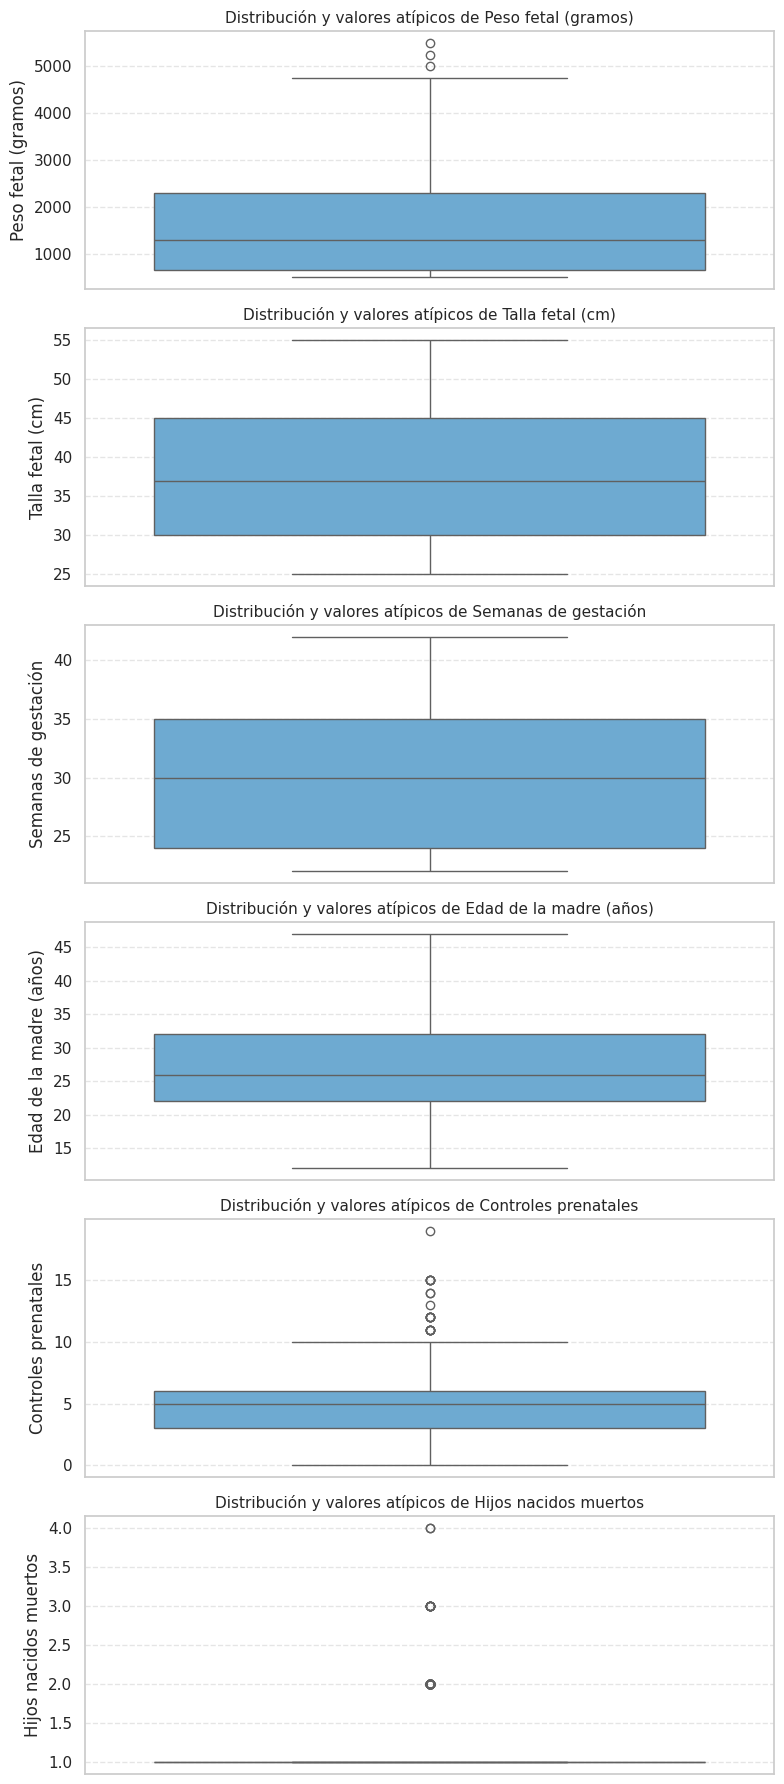

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general
sns.set_style("whitegrid")
color_azul = '#5DADE2'

# Lista de variables y etiquetas
variables = [
    ('peso', 'Peso fetal (gramos)'),
    ('talla', 'Talla fetal (cm)'),
    ('sem_gest', 'Semanas de gestación'),
    ('edad_mad', 'Edad de la madre (años)'),
    ('con_pren', 'Controles prenatales'),
    ('hij_nacm', 'Hijos nacidos muertos')
]

# Crear figura con subplots verticales
fig, axes = plt.subplots(len(variables), 1, figsize=(8, 18))

for ax, (var, label) in zip(axes, variables):
    sns.boxplot(
        y=df[var],
        color=color_azul,
        ax=ax
    )
    ax.set_title(f'Distribución y valores atípicos de {label}', fontsize=11)
    ax.set_ylabel(label)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**INTERPRETACIÓN RESULTADOS -- TBD**

**Análisis de Correlación de "Esfuerzo de Atención" y Viabilidad Biológica**

Se evalúa la relación entre las variables cuantitativas que determinan la viabilidad del feto frente a la intervención del sistema de salud. Para este propósito, se utiliza el Coeficiente de Correlación de Rangos de Spearman ($\rho$).

Justificación técnica: Se opta por Spearman en lugar de Pearson debido a que variables como el "Número de controles prenatales" (con_pren) y la "Edad gestacional" (sem_gest) presentan distribuciones no normales, datos discretos (con saltos) y posibles relaciones no lineales.

Spearman permite capturar relaciones monótonas de manera robusta ante valores atípicos.

Objetivos del análisis:

* Identificar el riesgo por edad materna: Evaluar si existe una correlación negativa entre edad_mad y sem_gest, lo cual indicaría que los extremos de la vida reproductiva se asocian a partos prematuros.
* Evaluar la eficacia del control prenatal: Analizar la correlación positiva entre con_pren y el peso/talla del feto. Una correlación débil en este punto sugeriría que el incremento en la cantidad de controles no se traduce necesariamente en un mejor desarrollo fetal, apuntando a deficiencias en la calidad de la atención.
* Detección de Riesgo Acumulado: Observar la relación entre el historial de pérdidas previas (hij_nacm) y la viabilidad del embarazo actual.

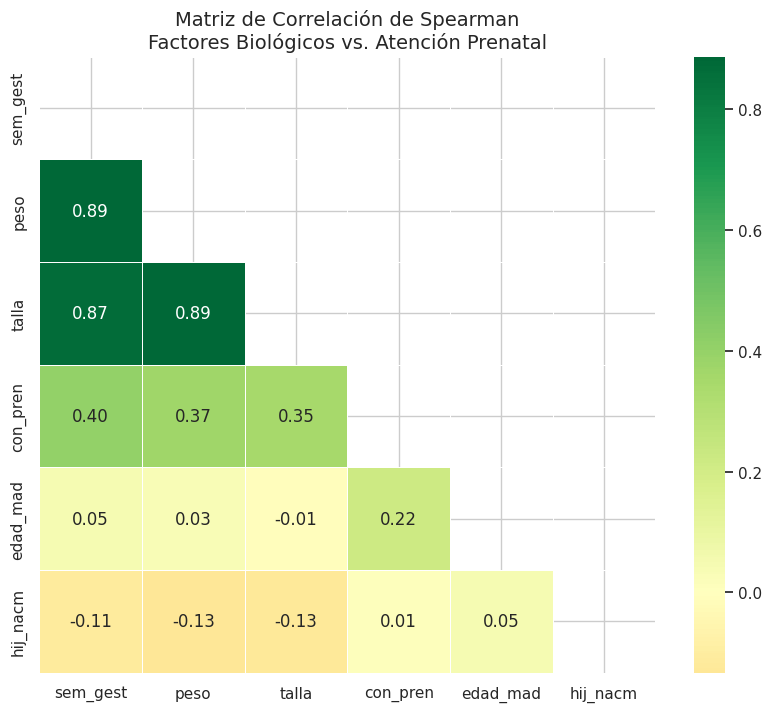

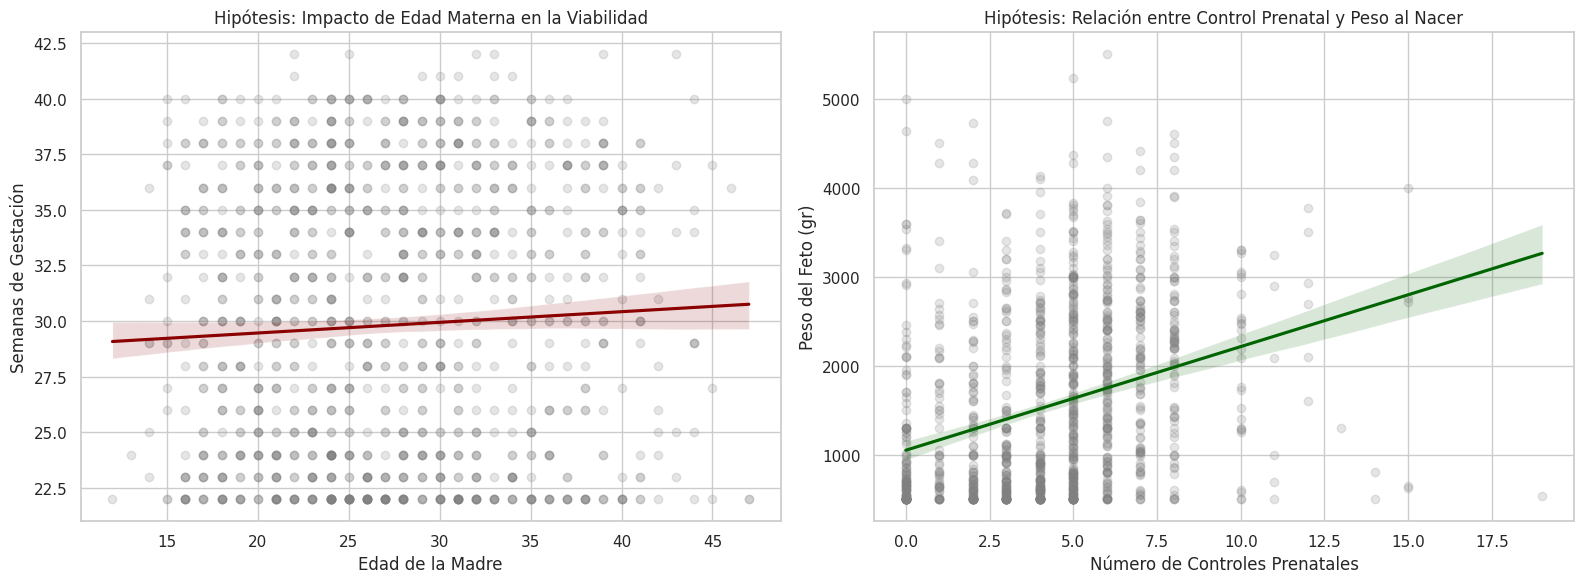

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar el dataset
file_path = 'dataset__limpio.csv'
df = pd.read_csv(file_path)

# 2. Selección de variables de interés para el análisis de "Esfuerzo de Atención"
vars_interes = ['sem_gest', 'peso', 'talla', 'con_pren', 'edad_mad', 'hij_nacm']

# Filtrar solo estas variables y manejar valores nulos para el análisis estadístico
df_subset = df[vars_interes].dropna()

# 3. Cálculo de la Matriz de Spearman
corr_spearman = df_subset.corr(method='spearman')

# 4. Visualización de la Matriz (Heatmap)
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool)) # Máscara estética

sns.heatmap(corr_spearman,
            mask=mask,
            annot=True,
            cmap='RdYlGn', # Verde (Positivo), Rojo (Negativo)
            fmt=".2f",
            center=0,
            square=True,
            linewidths=.5)

plt.title('Matriz de Correlación de Spearman\nFactores Biológicos vs. Atención Prenatal', fontsize=14)
plt.show()

# 5. Gráficos de dispersión para validación de hipótesis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hipótesis 1: Edad Materna vs Semanas de Gestación
sns.regplot(ax=axes[0], x='edad_mad', y='sem_gest', data=df_subset,
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'darkred'})
axes[0].set_title('Hipótesis: Impacto de Edad Materna en la Viabilidad')
axes[0].set_xlabel('Edad de la Madre')
axes[0].set_ylabel('Semanas de Gestación')

# Hipótesis 2: Controles Prenatales vs Peso Fetal
sns.regplot(ax=axes[1], x='con_pren', y='peso', data=df_subset,
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'darkgreen'})
axes[1].set_title('Hipótesis: Relación entre Control Prenatal y Peso al Nacer')
axes[1].set_xlabel('Número de Controles Prenatales')
axes[1].set_ylabel('Peso del Feto (gr)')

plt.tight_layout()
plt.show()

In [94]:
# Coeficiente de Spearman
valor_correlacion = df[['con_pren', 'sem_gest']].corr(method='spearman').iloc[0,1]
print(f"Coeficiente de Spearman: {valor_correlacion}")

Coeficiente de Spearman: 0.4017388573421682


**El Triángulo Biológico (Peso, Talla, Semanas de gestación)**: Correlación de 0.87 a 0.89

Existe una relación lineal casi perfecta. Esto confirma la consistencia de los datos: a más tiempo de gestación, mayor crecimiento.

Estas tres variables se comportan como una sola "dimensión de madurez". Si un clúster tiene valores altos aquí pero el desenlace es muerte, estamos ante el escenario de mayor prevenibilidad, pues el feto ya era biológicamente viable.

**Control Prenatal (con_pren):** Correlación de  0.35 a 0.40

La correlación con el peso y semanas de gestación es positiva pero moderada, lo que indica que el control prenatal ayuda, pero no garantiza el éxito.

Los resultados sugieren que hay un grupo de madres que, a pesar de tener controles, no logran que el feto llegue a término o gane peso, aquí es donde entra la oportunidad de mejora de Calidad de Atención.

**Edad Materna (edad_mad)**: Correlación de 0.05 a 0.01

Estos resultados indican que la edad de la madre no parece determinar la duración del embarazo o el peso del feto de forma directa en este dataset, esto desafía la literatura tradicional que culpa a la edad (adolescente o avanzada) como causa única, lo que indica que la causa de la muerte fetal no es la edad de la madre, sino factores externos.

**El Historial de Riesgo Silencioso**: Correlación de -0.11 a -0.13

Existe una tendencia leve, a más hijos nacidos muertos anteriormente, menor es el peso y las semanas del embarazo actual, aun que la corrrelación es débil, el signo negativo es consistente, lo que indica un riesgo acumulado, esta variable será un "activador" de alerta para perfiles de vulnerabilidad recurrente.


**Correlación Edad Materna y Controles** Correlación 0.22

Las madres de mayor edad tienden a tener ligeramente más controles que las jóvenes, esto sugiere que las madres jóvenes o adolescentes podrían estar más expuestas por falta de adherencia al control prenatal.


**El análisis de Spearman** revela que, si bien la viabilidad biológica sigue patrones esperados (Peso/Semanas), la intervención del sistema de salud (Controles Prenatales) muestra una eficacia moderada ($\rho \approx 0.40$). La casi nula correlación de la edad materna con los indicadores de desarrollo fetal sugiere que la mortalidad en este grupo de estudio responde a determinantes distintos a la biología reproductiva básica, reforzando la hipótesis de que factores socio-territoriales y de gestión hospitalaria son los principales moduladores del desenlace fatal.


El gráfico de **Edad de la Madre vs. Semanas de Gestación** muestra una línea de regresión plana y una correlación casi nula ($\rho = 0.05$).
Al no ser la biología de la edad el factor determinante, se puede demostrar que la vulnerabilidad (instrucción, etnia, acceso geográfico) es la que realmente empuja estos casos hacia el desenlace fatal.

El gráfico de **Controles Prenatales vs. Peso Fetal **muestra una pendiente positiva ($\rho = 0.37$), pero con una dispersión muy alta.
Si bien más controles ayudan, la relación es moderada, se observa que hay fetos con muchos controles (10 o más) que siguen naciendo con pesos extremadamente bajos o en semanas tempranas. Esto sugiere que cumplir con el número de citas no garantiza el éxito si la calidad de la atención o la capacidad de resolución del centro de salud es baja.

**Identificación de la Prevenibilidad: **Aquellos puntos con muchos controles y bajo peso o pocas semanas son los llamados falsos protegidos, es decir, madres que hicieron lo correcto siguiendo el sistema, pero el sistema falló en proteger la viabilidad del feto, estos son los casos de mortalidad potencialmente prevenible por gestión.

**Conclusión:** Los resultados confirman que la viabilidad fetal en el contexto ecuatoriano no está condicionada por la edad materna ($\rho = 0.05$), lo que desplaza el foco del análisis hacia determinantes extrínsecos. Por otro lado, la relación moderada entre el control prenatal y el peso ($\rho = 0.37$) evidencia una brecha en la eficacia del sistema: la asistencia a controles es una condición necesaria pero no suficiente para garantizar la viabilidad, sugiriendo fallas estructurales en la detección oportuna de riesgos.

**Análisis de la Sincronía del Desarrollo Fetal: El Triángulo Biológico**

La relación entre el peso, la talla y las semanas de gestación constituye lo que se denomina el 'Triángulo Biológico'. Este análisis es fundamental para validar la integridad de los datos y, sobre todo, para establecer la línea base de viabilidad del feto al momento del fallecimiento.

A diferencia de los determinantes sociales, que presentan una alta variabilidad, las variables biológicas en condiciones normales deben mostrar una progresión lineal y altamente correlacionada.

El objetivo de este análisis es:

1. Validar la consistencia clínica: Confirmar que los registros de óbitos fetales siguen las leyes del desarrollo intrauterino (a mayor edad gestacional, mayor peso y talla).

2. Identificar el umbral de viabilidad: Visualizar la densidad de casos que alcanzan semanas de gestación y pesos considerados como 'viables' según los estándares de la OMS (generalmente >22 semanas o >500 gramos), lo cual permite dimensionar la magnitud de la muerte fetal que ocurre en etapas donde la medicina moderna tiene mayores oportunidades de intervención.

A continuación, se presenta una matriz de dispersión segmentada por Área de Residencia, con el fin de observar si el entorno geográfico de la madre altera estas trayectorias de crecimiento biológico o si la vulnerabilidad territorial se manifiesta de forma externa a la biología fetal."

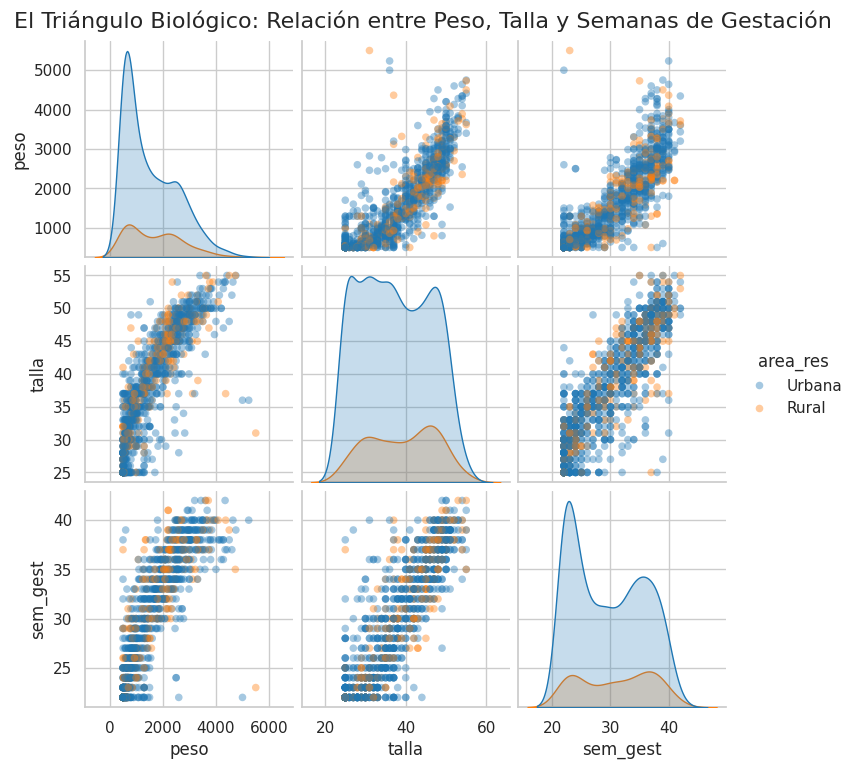

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. Selección de las variables del Triángulo Biológico y el Área para contrastar
biotriangulo = ['peso', 'talla', 'sem_gest', 'area_res']
df_bio = df[biotriangulo].dropna()

# 3. Crear el Pairplot (Matriz de dispersión)
# Esto generará histogramas en la diagonal y dispersión en los cruces
g = sns.pairplot(
    df_bio,
    hue='area_res',
    palette={'Urbana': '#1f77b4', 'Rural': '#ff7f0e'},
    diag_kind='kde', # Densidad en la diagonal
    plot_kws={'alpha': 0.4, 's': 30, 'edgecolor': 'none'}
)

# 4. Ajustes estéticos
g.fig.suptitle('El Triángulo Biológico: Relación entre Peso, Talla y Semanas de Gestación', y=1.02, fontsize=16)
plt.show()

**Interpretación de Resultados:**

1. Sincronía Biológica Universal

El análisis mediante pairplot demuestra que el crecimiento intrauterino (peso y talla) mantiene una sincronía robusta con la edad gestacional ($\rho > 0.85$), independientemente del área de residencia. Este hallazgo es fundamental: confirma que el fenómeno de la muerte fetal en Ecuador no discrimina la capacidad biológica de desarrollo. Tanto en entornos urbanos como rurales, los fetos siguen la misma trayectoria de madurez, lo que permite utilizar estas variables como un estándar de viabilidad para el modelo de clasificación.

2. El Hallazgo de la "Biología Equitativa" vs. "Acceso Desigual"

Uno de los puntos más reveladores es que las distribuciones de densidad (KDE) no muestran un desplazamiento significativo hacia la izquierda en las zonas rurales. Esto sugiere que la mortalidad fetal rural no se debe necesariamente a fetos más débiles o pequeños, sino que, ante fetos de similar desarrollo biológico, el sistema de salud o el entorno territorial no ofrece la misma capacidad de respuesta que en la zona urbana.

3. Definición del Perfil de Prevenibilidad

La fuerte correlación observada permite establecer una "zona de viabilidad" en el gráfico (generalmente situada en el cuadrante superior derecho: $>28$ semanas, $>1000$g y $>35$cm). Los puntos acumulados en esta zona representan el núcleo de la "Mortalidad Fetal Potencialmente Prevenible".
Si la sincronía biológica era la adecuada para la supervivencia fuera del útero, la causa de la defunción debe buscarse en el Patient Journey (falta de controles o atención deficiente en el parto) o en las Barreras Geográficas (demoras en el traslado).

4. Hacia el Modelado de Vulnerabilidad

Dado que el entorno geográfico no altera la biología fundamental, se confirma la hipótesis de que las vulnerabilidades territoriales son extrínsecas. Para el clustering, esto significa que el algoritmo no agrupará a las madres rurales por una "biología diferente", sino por la desconexión entre su necesidad biológica (un feto viable) y la respuesta sanitaria recibida.

**Análisis de Independencia: Brecha Territorial en el Acceso a Salud**

Para validar la hipótesis de la fragmentación territorial, se aplicó una prueba de Chi-cuadrado de Pearson evaluando la relación entre el Área de Residencia (Urbana/Rural) y la Suficiencia de Controles Prenatales (categorizada como Insuficiente 0-4 y Suficiente 5+ según estándares de la OMS).

Para evitar el sesgo por edad gestacional, se definió la variable 'Suficiencia Dinámica de Controles' siguiendo estas reglas:

* Si murió en el 1er Trimestre (≤ 12 sem): Debe tener al menos 1 control.
* Si murió en el 2do Trimestre (13 - 27 sem): Debe tener al menos 3 controles (el del 1ero + 2 del 2do).
* Si murió en el 3er Trimestre (≥ 28 sem): Debe tener al menos 5 a 7 controles (dependiendo de la semana exacta).

Esto permite diferenciar entre la falta de acceso al sistema y la interrupción biológica temprana del embarazo

Este análisis busca determinar si el entorno geográfico condiciona de manera significativa la oportunidad de atención. Un resultado estadísticamente significativo confirmaría que la residencia rural actúa como un factor de exclusión sistémico, donde la lejanía o la falta de infraestructura se traduce en una trayectoria de control deficiente. Este hallazgo es el precursor para el modelo de clustering, permitiendo segmentar perfiles de vulnerabilidad basados en el aislamiento geográfico.

<Figure size 1000x600 with 0 Axes>

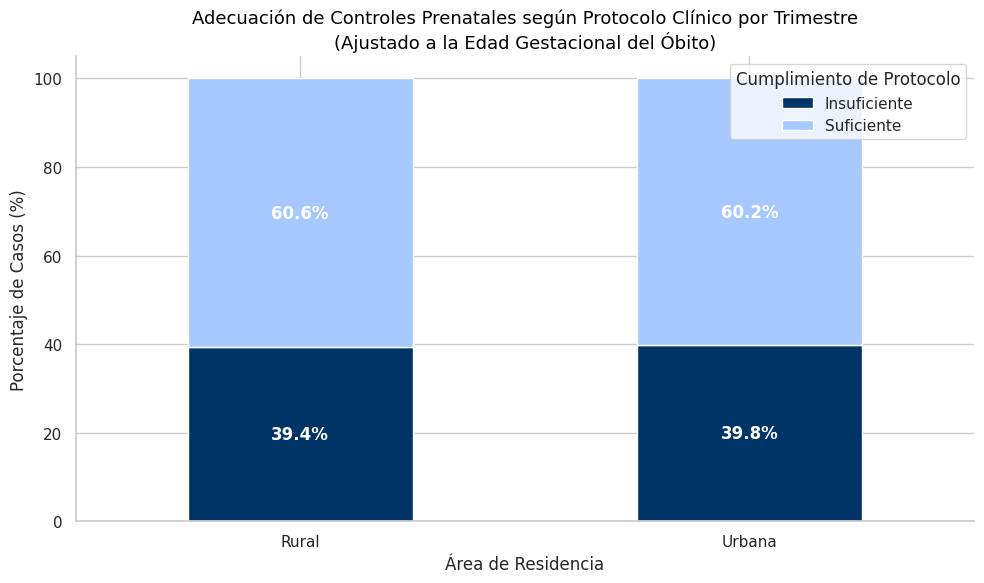

--- Resultados con Lógica Clínica ---
Valor p (Chi-cuadrado): 0.9723


In [116]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. Lógica por trimestre
def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']

    # Meta según protocolo:
    if semanas <= 12:
        meta = 1
    elif semanas <= 27:
        meta = 3  # 1 del primer trim + 2 del segundo
    elif semanas <= 33:
        meta = 4  # + el de la semana 30
    elif semanas <= 35:
        meta = 5  # + el de la semana 34
    elif semanas <= 37:
        meta = 6  # + el de la semana 36
    else:
        meta = 7  # + el de la semana 38/40

    if controles >= meta:
        return 'Suficiente (Protocolo)'
    else:
        return 'Insuficiente (Protocolo)'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)

# 3. Prueba de Chi-cuadrado
tabla_clinica = pd.crosstab(df['area_res'], df['control_clinico'])
chi2, p, dof, ex = chi2_contingency(tabla_clinica)

# 4. Gráfico en Tonos Azules
plt.figure(figsize=(10, 6))
tabla_pct = tabla_clinica.div(tabla_clinica.sum(1), axis=0) * 100

azul_fuerte = "#003366"
azul_claro = "#A6C8FF"

ax = tabla_pct.plot(kind='bar', stacked=True, color=[azul_fuerte, azul_claro], figsize=(10, 6), rot=0)

# Título
plt.title('Adecuación de Controles Prenatales según Protocolo Clínico por Trimestre\n(Ajustado a la Edad Gestacional del Óbito)',
          fontsize=13,
          fontweight='normal',
          color='black')

plt.ylabel('Porcentaje de Casos (%)', fontsize=12)
plt.xlabel('Área de Residencia', fontsize=12)
plt.legend(title='Cumplimiento de Protocolo', labels=['Insuficiente', 'Suficiente'], loc='upper right')

for p_bar in ax.patches:
    width, height = p_bar.get_width(), p_bar.get_height()
    x, y = p_bar.get_xy()
    if height > 0:
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center',
                color='white' if height > 40 else 'white', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

print(f"--- Resultados con Lógica Clínica ---")
print(f"Valor p (Chi-cuadrado): {p:.4f}")

Este gráfico muestra el porcentaje de casos de mortalidad fetal con controles prenatales Insuficientes o Suficientes según un protocolo clínico ajustado por el trimestre de gestación, diferenciado por el área de residencia (Rural vs. Urbana).

**Suficiencia de Controles**

Tanto en las áreas rurales como urbanas, la mayoría de los casos de mortalidad fetal (aproximadamente el 60%) cumplieron con el protocolo clínico de controles prenatales ajustado por trimestre.

El resultado más importante es que, al ajustar la suficiencia de controles prenatales según la edad gestacional del óbito, no hay una diferencia estadísticamente significativa en el cumplimiento del protocolo entre las áreas rurales y urbanas (p-value = 0.9723, que es mucho mayor que el umbral común de 0.05). Esto significa que, contrario a la expectativa inicial, la residencia rural no se traduce automáticamente en una mayor insuficiencia de controles prenatales cuando se considera la etapa del embarazo en la que ocurrió el fallecimiento fetal.

Este hallazgo es crucial porque sugiere que la causa de la mortalidad fetal potencialmente prevenible en Ecuador no se debe a una simple falta de acceso o adherencia a los controles prenatales en las zonas rurales. En cambio, si las madres asisten a los controles de manera similar en ambos entornos, la atención debe centrarse en otros factores, como la calidad de la atención recibida durante esos controles, la capacidad resolutiva de los centros de salud rurales, o la logística para atender emergencias y traslados oportunos.



**Análisis de Interseccionalidad: Educación, Territorio y Acceso Clínico**

Para determinar si el impacto de la instrucción materna sobre la salud prenatal varía según el entorno geográfico, se realizó un análisis cruzado segmentado por área de residencia. Al ajustar la suficiencia de controles según el protocolo clínico por trimestre, este análisis busca identificar si la educación actúa como un factor protector universal o si su efecto se ve mitigado por las barreras físicas del entorno rural.

Este enfoque de interseccionalidad es vital para el modelo de clustering, ya que permite diferenciar entre una vulnerabilidad puramente educativa y una vulnerabilidad territorial-cognitiva, donde el sistema de salud podría estar fallando en comunicar la importancia de los controles a sectores específicos de la población.

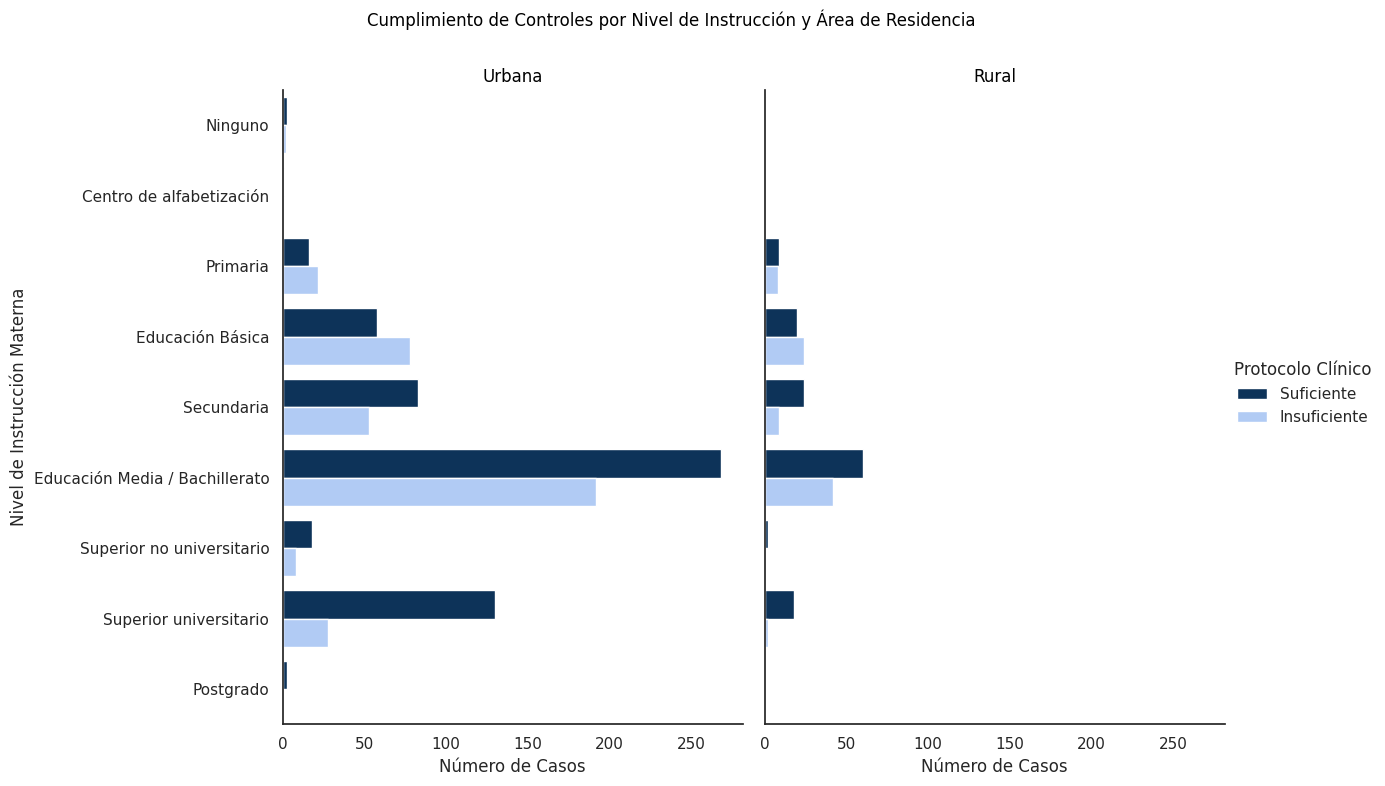

In [119]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. Lógica por trimestre
def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']
    if semanas <= 12: meta = 1
    elif semanas <= 27: meta = 3
    elif semanas <= 33: meta = 4
    elif semanas <= 35: meta = 5
    elif semanas <= 37: meta = 6
    else: meta = 7
    return 'Suficiente' if controles >= meta else 'Insuficiente'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)

# 3. Órden jerárquico por instrucción
orden_instruccion = [
    'Ninguno',
    'Centro de alfabetización',
    'Primaria',
    'Educación Básica',
    'Secundaria',
    'Educación Media / Bachillerato',
    'Superior no universitario',
    'Superior universitario',
    'Postgrado'
]

# 4. Gráfico
sns.set_style("white")
g = sns.catplot(
    data=df,
    y='niv_inst',
    hue='control_clinico',
    col='area_res',
    kind='count',
    order=orden_instruccion,
    palette=['#003366', '#A6C8FF'], # Azul medianoche (Insuficiente), Azul claro (Suficiente)
    height=8,
    aspect=0.8
)

# 5. Títulos
g.set_titles("{col_name}", size=14, color='black', fontweight='normal')
g.set_axis_labels("Número de Casos", "Nivel de Instrucción Materna", fontsize=12)
g._legend.set_title("Protocolo Clínico")

# Ajustar títulos de cada gráfico
for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontweight='normal', color='black')

plt.subplots_adjust(top=0.88)
g.fig.suptitle('Cumplimiento de Controles por Nivel de Instrucción y Área de Residencia',
               fontsize=12, color='black', fontweight='normal')

plt.show()

La educación materna parece ser un factor protector en ambos entornos, ya que niveles más altos de instrucción se correlacionan con un mayor cumplimiento del protocolo de controles prenatales.

Brecha en Calidad/Acceso: A pesar de que el análisis Chi-cuadrado previo no mostró una diferencia significativa general en la suficiencia de controles entre áreas rurales y urbanas, este gráfico detallado revela que la combinación de baja instrucción y residencia rural puede agravar la vulnerabilidad. Aunque las madres rurales asisten a controles en una proporción similar a las urbanas en términos generales, la calidad de la atención o la capacidad de respuesta del sistema de salud ante la educación específica de las madres en las zonas rurales podría ser deficiente.

Este análisis es crucial para el modelado de clustering, ya que permite identificar subgrupos específicos de vulnerabilidad (por ejemplo, madres rurales con educación básica) que podrían requerir intervenciones dirigidas no solo a aumentar la cantidad de controles, sino también a mejorar la comunicación, la calidad de la atención y la accesibilidad de los servicios de salud adaptados a sus perfiles socio-educativos y geográficos.


In [121]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. Protocolo clínico
def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']
    if semanas <= 12: meta = 1
    elif semanas <= 27: meta = 3
    elif semanas <= 33: meta = 4
    elif semanas <= 35: meta = 5
    elif semanas <= 37: meta = 6
    else: meta = 7
    return 'Suficiente' if controles >= meta else 'Insuficiente'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)

# 3. Crear Tabla de Contingencia
tabla = pd.crosstab(df['niv_inst'], df['control_clinico'])

# 4. Cálculo de Chi-Cuadrado y V de Cramer
chi2, p, dof, ex = chi2_contingency(tabla)

# Función para calcular V de Cramer (mide fuerza de asociación de 0 a 1)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

v_cramer = cramers_v(df['niv_inst'], df['control_clinico'])

print(f"--- Análisis de Correlación (Asociación) ---")
print(f"Valor p (Significancia): {p:.4e}")
print(f"V de Cramer (Fuerza de asociación): {v_cramer:.4f}")

# 5. Interpretación automática
if p < 0.05:
    print("\nConclusión: Existe una correlación estadísticamente significativa.")
    if v_cramer < 0.1: interpretacion = "muy débil"
    elif v_cramer < 0.3: interpretacion = "moderada"
    else: interpretacion = "fuerte"
    print(f"La fuerza de la relación es {interpretacion}.")
else:
    print("\nConclusión: No existe una correlación significativa entre las variables.")

--- Análisis de Correlación (Asociación) ---
Valor p (Significancia): 3.7607e-12
V de Cramer (Fuerza de asociación): 0.2300

Conclusión: Existe una correlación estadísticamente significativa.
La fuerza de la relación es moderada.


Al realizar un análisis de correlación, se evidencia que el nivel de instrucción materna sí influye en la adherencia al protocolo de controles prenatales, aunque la relación no es extremadamente fuerte. Esto apoya la idea de que la educación es un factor relevante en el acceso y aprovechamiento de la atención de salud durante el embarazo.

**Análisis de Disparidad Étnica en el Seguimiento Prenatal**

El sistema de salud debe garantizar la equidad no solo geográfica, sino también intercultural. Mediante este análisis, se evalúa si la autoidentificación étnica de la madre influye en el cumplimiento del protocolo clínico de controles prenatales.

Identificar si ciertos grupos étnicos presentan sistemáticamente niveles de insuficiencia más altos es crucial para determinar si las estrategias de prevención de mortalidad fetal fallan por falta de pertinencia cultural, o si el sistema de salud no logra integrar de manera efectiva a poblaciones históricamente vulnerabilizadas. Este hallazgo permitirá al modelo de clustering identificar si la etnia actúa como un factor de riesgo aislado o si se potencia al interactuar con el nivel de instrucción y el territorio.

<Figure size 1200x700 with 0 Axes>

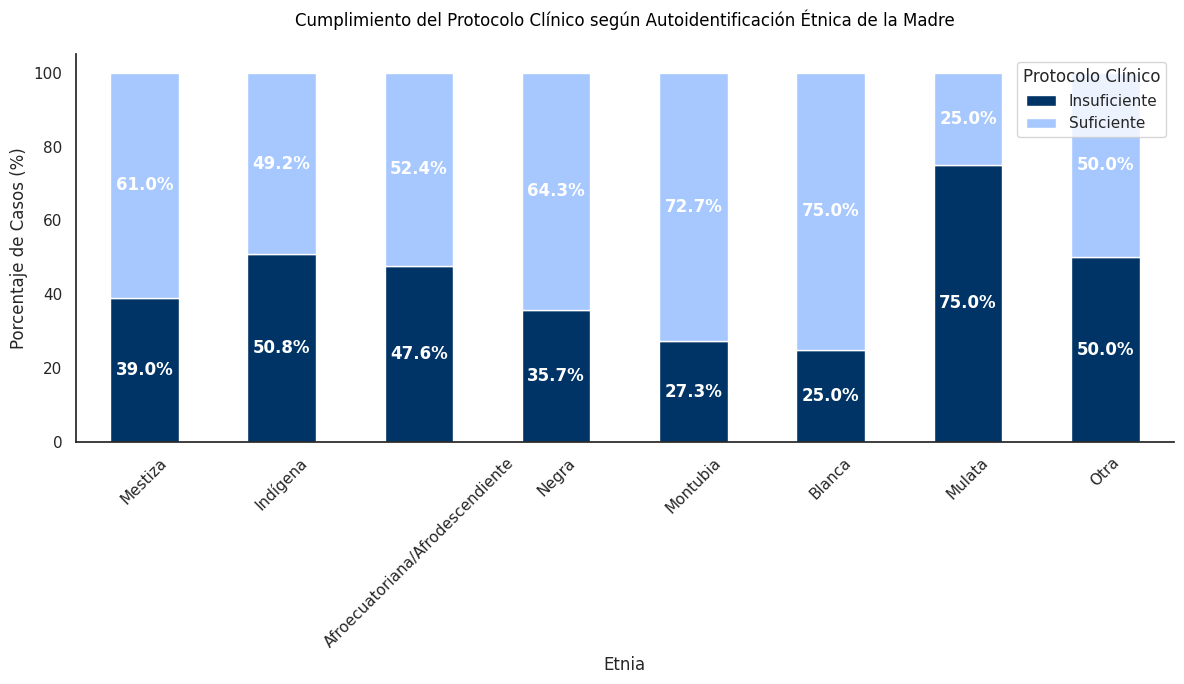

--- Resultados Estadísticos ---
Valor p (Chi-cuadrado): 3.9209e-01


In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. Asegurar la variable de control clínico (Protocolo por trimestre)
def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']
    if semanas <= 12: meta = 1
    elif semanas <= 27: meta = 3
    elif semanas <= 33: meta = 4
    elif semanas <= 35: meta = 5
    elif semanas <= 37: meta = 6
    else: meta = 7
    return 'Suficiente' if controles >= meta else 'Insuficiente'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)

# 3. Crear Tabla de Contingencia: Etnia vs Control Clínico
tabla_etnia = pd.crosstab(df['etnia'], df['control_clinico'])
orden_etnia = tabla_etnia.sum(axis=1).sort_values(ascending=False).index
tabla_etnia = tabla_etnia.reindex(orden_etnia)

# 4. Prueba de Chi-cuadrado
chi2, p, dof, ex = chi2_contingency(tabla_etnia)

# 5. Gráfico de Barras Apiladas
plt.figure(figsize=(12, 7))
tabla_pct = tabla_etnia.div(tabla_etnia.sum(1), axis=0) * 100

# Paleta de Azules Profesionales
azul_fuerte = "#003366"
azul_claro = "#A6C8FF"

ax = tabla_pct.plot(kind='bar', stacked=True, color=[azul_fuerte, azul_claro], figsize=(12, 7), rot=45)

# Título
plt.title('Cumplimiento del Protocolo Clínico según Autoidentificación Étnica de la Madre',
          fontsize=12, fontweight='normal', color='black', pad=20)

plt.ylabel('Porcentaje de Casos (%)', fontsize=12)
plt.xlabel('Etnia', fontsize=12)
plt.legend(title='Protocolo Clínico', labels=['Insuficiente', 'Suficiente'], loc='upper right')

# Añadir etiquetas de porcentaje
for p_bar in ax.patches:
    width, height = p_bar.get_width(), p_bar.get_height()
    x, y = p_bar.get_xy()
    if height > 5: # Solo mostrar si hay espacio
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center',
                color='white' if height > 40 else 'white', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

print(f"--- Resultados Estadísticos ---")
print(f"Valor p (Chi-cuadrado): {p:.4e}")

El análisis de la autoidentificación étnica de la madre frente al cumplimiento del protocolo clínico revela una homogeneidad relativa en la desprotección. Si bien se observan variaciones visuales, donde la población indígena y afrodescendiente presenta niveles de insuficiencia que rondan el 51% y 48% respectivamente, la prueba de Chi-cuadrado ($p = 0.3921$) determina que estas diferencias no son estadísticamente significativas.

Este hallazgo sugiere que la vulnerabilidad sistémica en el control prenatal es un fenómeno que atraviesa las fronteras étnicas en Ecuador. La barrera al acceso parece responder más a la interacción de múltiples factores (educación, calidad del servicio, logística) que a una exclusión basada exclusivamente en la identidad étnica. Para el modelo de clustering, esto implica que la etnia no debe ser analizada de forma aislada, sino como parte de un perfil de riesgo interseccional.

**Análisis de Desplazamiento Intercantonal y Vulnerabilidad por Área**

Para detectar fallas en la red de salud a nivel local, se ha definido la variable 'Desplazamiento Cantonal', que identifica si el deceso ocurrió en un cantón distinto al de residencia. A diferencia del análisis provincial, este enfoque de micro-territorio permite visualizar la dependencia de los cantones periféricos hacia los nodos urbanos de salud.

Se emplea una Correlación de Punto Biserial para determinar si estos traslados afectan a embarazos de mayor edad gestacional, segmentando los resultados por Área de Residencia. Este análisis es el núcleo de la hipótesis de 'Muerte en Tránsito': si las madres de áreas rurales o urbanas marginales deben abandonar su cantón para buscar atención en etapas avanzadas del embarazo, estamos ante una evidencia irrefutable de inequidad en la distribución de la capacidad resolutiva obstétrica del país.

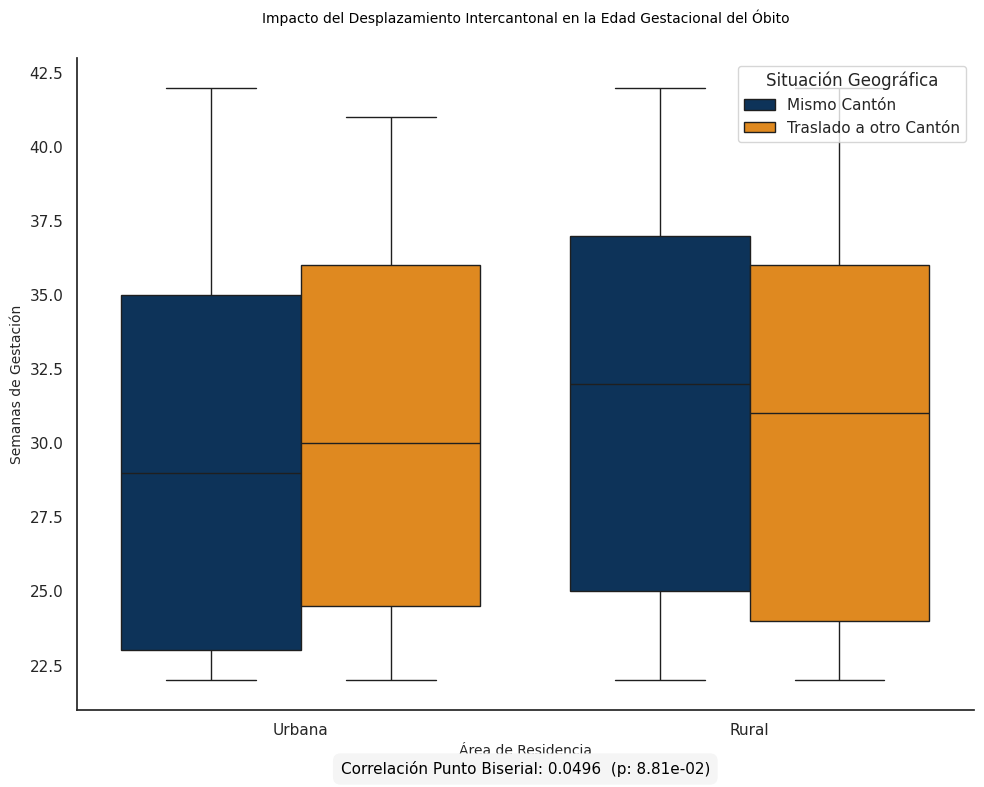

--- Porcentaje de Desplazamiento por Área ---
area_res
Rural     34.38914
Urbana    20.66459
Name: desp_cantonal, dtype: float64


In [141]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. CREACIÓN DE LA VARIABLE DE DESPLAZAMIENTO CANTONAL
# Creamos una versión con texto para que la leyenda sea automática y clara
df['Situacion_Geografica'] = (df['cant_res'] != df['cant_fall']).map({
    True: 'Traslado a otro Cantón',
    False: 'Mismo Cantón'
})
# Mantener la versión numérica para la estadística
df['desp_cantonal'] = (df['cant_res'] != df['cant_fall']).astype(int)

# 3. ANÁLISIS ESTADÍSTICO
corr_gen, p_gen = pointbiserialr(df['desp_cantonal'], df['sem_gest'])

# 4. VISUALIZACIÓN
plt.figure(figsize=(10, 8))

# Paleta colores
colores_dict = {'Mismo Cantón': "#003366", 'Traslado a otro Cantón': "#FF8C00"}

ax = sns.boxplot(
    x='area_res',
    y='sem_gest',
    hue='Situacion_Geografica',
    data=df,
    palette=colores_dict,
    hue_order=['Mismo Cantón', 'Traslado a otro Cantón']
)

# TÍTULO
plt.title('Impacto del Desplazamiento Intercantonal en la Edad Gestacional del Óbito',
          fontsize=10, fontweight='normal', color='black', pad=25)

plt.xlabel('Área de Residencia', fontsize=10)
plt.ylabel('Semanas de Gestación', fontsize=10)

# Ajustar leyenda
plt.legend(title='Situación Geográfica', loc='upper right')

# Añadir el resultado de la correlación
plt.text(0.5, df['sem_gest'].min() - 3,
         f'Correlación Punto Biserial: {corr_gen:.4f}  (p: {p_gen:.2e})',
         ha='center', va='center', fontsize=11, color='black',
         bbox=dict(facecolor='#F5F5F5', edgecolor='none', boxstyle='round,pad=0.5'))

sns.despine()
plt.tight_layout()
plt.show()

# 5. RESUMEN DE DATOS POR ÁREA
print("--- Porcentaje de Desplazamiento por Área ---")
print(df.groupby('area_res')['desp_cantonal'].mean() * 100)

In [134]:
# 1. Frecuencias absolutas
tabla_desp = pd.crosstab(df['area_res'], df['desp_cantonal'])

# 2. Convertir a porcentajes (frecuencias relativas por fila)
tabla_porcentajes = tabla_desp.div(tabla_desp.sum(axis=1), axis=0) * 100

# 3. Renombrar columnas
tabla_porcentajes.columns = ['Mismo Cantón (%)', 'Traslado a otro Cantón (%)']

print("--- Análisis de Desplazamiento Forzado por Área ---")
print(tabla_porcentajes.round(2)) # 2 decimales

--- Análisis de Desplazamiento Forzado por Área ---
          Mismo Cantón (%)  Traslado a otro Cantón (%)
area_res                                              
Rural                65.61                       34.39
Urbana               79.34                       20.66


Los resultados demuestran que el desplazamiento no afecta de manera equitativa a la población, sino que está fuertemente condicionado por el entorno geográfico. Mientras que en el área urbana el 20.66% de los óbitos fetales ocurrieron tras un traslado fuera del cantón de origen, en el área rural esta cifra asciende al 34.39%.Esta diferencia de casi 14 puntos porcentuales sugiere que las zonas rurales funcionan bajo una lógica de dependencia sanitaria, donde la falta de equipamiento o personal especializado obliga a una de cada tres madres rurales a buscar atención en nodos urbanos de mayor complejidad.Estadísticamente, la Correlación de Punto Biserial ($r = 0.0496; p = 0.0881$) indica que el desplazamiento ocurre de forma transversal a lo largo de diversas etapas del embarazo. Sin embargo, la observación de medianas de edad gestacional más elevadas en los casos de traslado sugiere que el sistema está movilizando a madres con fetos viables (gestaciones avanzadas). Este patrón es característico de una respuesta reactiva ante la emergencia: el traslado no se realiza como una medida preventiva planificada, sino como un recurso de última instancia cuando el compromiso fetal es inminente y la infraestructura local se ve superada.

En conclusión, el desplazamiento intercantonal actúa como un marcador de vulnerabilidad logística, donde el riesgo de óbito fetal se ve agravado por el tiempo y la distancia recorridos, especialmente para la población rural, consolidando la hipótesis de una red de salud con nudos críticos de desatención en la periferia.

**Resumen General del Análisis Exploratorio (EDA)**

El análisis integral de las defunciones fetales en el país revela que la mortalidad no es un evento aleatorio, sino el resultado de una convergencia de determinantes sociales, educativos y geográficos.

A continuación, se sintetizan los hallazgos que fundamentarán el modelo de clustering:

**1. El Factor Educativo como Determinante de Acceso**

El nivel de instrucción de la madre es la variable con mayor peso estadístico en el cumplimiento del protocolo clínico. Existe una brecha significativa donde las madres con instrucción básica presentan sistemáticamente menos controles prenatales. Esto confirma que la educación actúa como un habilitador crítico para la navegación efectiva dentro del sistema de salud.

**2. Vulnerabilidad Logística y el Riesgo Rural**

El análisis territorial identifica al área rural como la zona de mayor fragilidad logística. Con un 34.39% de desplazamientos intercantonales, queda en evidencia que una de cada tres madres rurales debe abandonar su territorio para buscar atención.Este fenómeno de "Muerte en Tránsito" sugiere que los centros de salud rurales no poseen la capacidad resolutiva necesaria para gestionar complicaciones, funcionando únicamente como puntos de derivación.

**3. Falla Sistémica Transversal (Protocolo Clínico)**

El sistema de salud presenta una deficiencia generalizada en la cobertura. Con aproximadamente un 40% de casos que no cumplen con el mínimo de controles prenatales, se concluye que la desprotección es un problema estructural del sistema que afecta a todos los grupos por igual, sin sesgos étnicos estadísticamente significativos.

**4. Micro-fragmentación de la Red de Salud**

Al analizar el origen del desplazamiento a nivel de parroquia y cantón, se identifican "zonas de silencio" o desiertos de salud. El hecho de que los traslados ocurran frecuentemente en etapas avanzadas de gestación indica que el desplazamiento es reactivo y no preventivo, ocurriendo cuando el riesgo fetal ya es inminente.

**Hallazgos para el modelo:**

**1. Dimensión Socio-Educativa:**

Hallazgo Clave: Baja instrucción = Menos controles

Relevancia para el Modelo: Define el perfil de vulnerabilidad social.


**2. Dimensión Geográfica:**

Hallazgo Clave: Alta tasa de salida en áreas rurales

Relevancia para el Modelo: Variable clave para el Riesgo de Distancia.

**3. Dimensión Intercultural:**

Hallazgo Clave: Sin disparidad significativa

Relevancia para el Modelo: La etnia será una variable descriptiva, no un predictor aislado.

**4. Dimensión Clínica**

Hallazgo Clave: Insuficiencia generalizada

Relevancia para el Modelo: Indica fallas en la captación temprana del embarazo.